In [45]:
import math
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [32]:
# Simple NN: u(x,y) -> scalar
class Net(nn.Module):
    def __init__(self, layers=(2, 20, 1)):
        super().__init__()
        net = []
        for i in range(len(layers) - 2):  # hidden layers
            net.append(nn.Linear(layers[i], layers[i+1]))
            net.append(nn.Tanh())
        net.append(nn.Linear(layers[-2], layers[-1]))  # output layer
        self.net = nn.Sequential(*net)
    def forward(self, r, theta):  # force the neural network to think in Cartesian coordinates
        # Coordinate embedding: (r, theta) -> (x, y) to enforce geometric continuity.
        x = r * torch.cos(theta)
        y = r * torch.sin(theta)
        X = torch.cat([x, y], dim=1) # Network sees x,y
        return self.net(X)

Write in polar coordinates the Neumann problem for the Laplace equation in a half disk
$D = \{x^2 + y^2 < 9, \; y > 0\},$

$$
\begin{cases}
\Delta u = 0 \quad \text{in } D, \\
\frac{\partial u}{\partial \vec{\nu}} =
\begin{cases}
x^2 - \frac{9}{2}, \quad x^2 + y^2 = 9, \\
0, \quad  y = 0.
\end{cases}
\end{cases}
$$

**Solution:** The domain is $D = \{0 < r < 3, \; 0 < \theta < \pi\}$.
The normal derivative on the boundary is

$$
\frac{\partial}{\partial \vec{\nu}} =
\begin{cases}
\frac{\partial}{\partial r}, & \text{on } r = 3, \\
- \frac{\partial}{\partial \theta}, & \text{on } \theta = 0, \\
\frac{\partial}{\partial \theta}, & \text{on } \theta = \pi.
\end{cases}
$$

Since $x^2 = (r \cos \theta)^2 = 9 \cos^2 \theta$ on the boundary,
we get the problem, for $v(r,\theta) = u(x,y)$,

$$
\begin{cases}
\dfrac{\partial^2 v}{\partial r^2} + \dfrac{1}{r} \dfrac{\partial v}{\partial r} + \dfrac{1}{r^2} \dfrac{\partial^2 v}{\partial \theta^2} = 0, \quad 0 < r < 3, \; 0 < \theta < \pi, \\

\dfrac{\partial v}{\partial r}(3,\theta) = 9 \cos^2 \theta - \frac{9}{2}, \\

\dfrac{\partial v}{\partial \theta}(r,0) = \dfrac{\partial v}{\partial \theta}(r,\pi) = 0.
\end{cases}
$$


In [40]:
# --- Collocation points ---
N_f = 500  # number of collocation points
r_f = torch.rand(N_f, 1) * 3.0
r_f.requires_grad_()
theta_f = torch.rand(N_f, 1) * math.pi
theta_f.requires_grad_()
u_exact = (3.0/4.0 * torch.pow(r_f, 2) * torch.cos(2 * theta_f)).detach()

# --- Boundary points r ---
r_bc = torch.full((200, 1), 3.0, requires_grad=True)
theta_bc = torch.rand(200,1) * math.pi
u_r_bc = 9 * torch.pow(torch.cos(theta_bc), 2) - 9.0/2.0

# --- Sort of initial conditions (BC of theta) ---
r_ic = torch.rand(200, 1) * 3.0
theta_ic = torch.cat([torch.zeros(100, 1), torch.full((100,1), math.pi)], dim=0)
theta_ic = theta_ic.detach().requires_grad_(True)

In [41]:
net = Net((2, 20, 50, 100, 150, 100, 50, 20, 1))

# Stochastic Gradient Descent works much worse here
# optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)  # SGD (Stochastic Gradient Descent) with Momentum
optimizer = optim.Adam(net.parameters(), lr=1e-3)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.8,
    patience=30
)

mse_errors = []
l2_errors = []
l2_relative_errors = []
lrs = []

for epoch in range(6001):
    optimizer.zero_grad()

    # PDE residual
    u_f = net(r_f, theta_f)
    u_theta = torch.autograd.grad(u_f.sum(), theta_f, create_graph=True)[0]
    u_r = torch.autograd.grad(u_f.sum(), r_f ,create_graph=True)[0]

    u_theta2 = torch.autograd.grad(u_theta, theta_f, torch.ones_like(u_theta), create_graph=True)[0]
    u_rr = torch.autograd.grad(u_r, r_f, torch.ones_like(u_r), create_graph=True)[0]
    f_res = torch.pow(r_f, 2) * u_rr + r_f * u_r + u_theta2
    loss_pde = torch.mean(f_res**2)

    # Boundary loss r
    u_bc_pred = net(r_bc, theta_bc)
    u_bc_r_pred = torch.autograd.grad(u_bc_pred.sum(), r_bc, create_graph=True)[0]
    loss_bc = torch.mean((u_r_bc - u_bc_r_pred) ** 2)

    # initial condition loss (BC of theta)
    u_ic = net(r_ic, theta_ic)
    u_ic_theta = torch.autograd.grad(u_ic.sum(), theta_ic, create_graph=True)[0]
    loss_ic = torch.mean(u_ic_theta ** 2)

    loss = loss_pde + loss_bc + loss_ic
    loss.backward()
    optimizer.step()
    scheduler.step(loss.detach())

    l2_errors.append(torch.norm(u_f - u_exact).detach().item())
    l2_relative_errors.append(torch.norm(u_f - u_exact).detach().item() / torch.norm(u_exact).detach().item())
    mse_errors.append(torch.mean((u_f - u_exact) ** 2).detach().item())
    lrs.append(optimizer.param_groups[0]['lr'])

    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

Epoch 0, Loss: 10.407895
Epoch 1000, Loss: 0.005180
Epoch 2000, Loss: 0.002058
Epoch 3000, Loss: 0.001209
Epoch 4000, Loss: 0.000812
Epoch 5000, Loss: 0.000598
Epoch 6000, Loss: 0.000480


Separating variables $v(r,\theta) = R(r)H(\theta)$, we obtain the two problems

$$
\begin{cases}
H'' + \lambda H = 0, & 0 < \theta < \pi, \\
H'(0) = H'(\pi) = 0;
\end{cases}
\qquad
\begin{cases}
r^2 R'' + rR' + \lambda R = 0, & 0 < r < 3, \\
|R(0)| < \infty.
\end{cases}
$$

The first one gives the eigenfunctions $H_n(\theta) = \cos(n\theta)$ and eigenvalues $\lambda_n = n^2, \; n \geq 0$.

We then see, looking at the boundary condition

$$
\frac{\partial v}{\partial r}(3,\theta) = 9 \cos^2 \theta - \frac{9}{2} = \frac{9}{2} - \frac{9}{2} + \frac{9}{2} \cos 2\theta.
$$

that we only need to consider the cases $n = 0, 2$. As to the radial problem, we have $R_0(r) = 1$, $R_2(r) = r^2$. Then the solution takes the form
$$
v(r, \theta) = c_0 + c_2r^2 \cos 2\theta.
$$
The boundary condition is
$$
\frac{9}{2} \cos 2\theta = \frac{\partial v}{\partial r}(3, \theta) = 6c_2 \cos 2\theta,
$$
so that $6c_2 = 9/2$. We obtain $c_2 = 3/4$. Finally the solution is
$$
v(r, \theta) = c_0 + \frac{3}{4} r^2 \cos 2\theta, \quad c_0 \in \mathbb{R}
$$
In cartesian coordinates it is
$$
u(x, y) = c_0 + \frac{3}{4}(x^2 - y^2), \quad c_0 \in \mathbb{R}.
$$


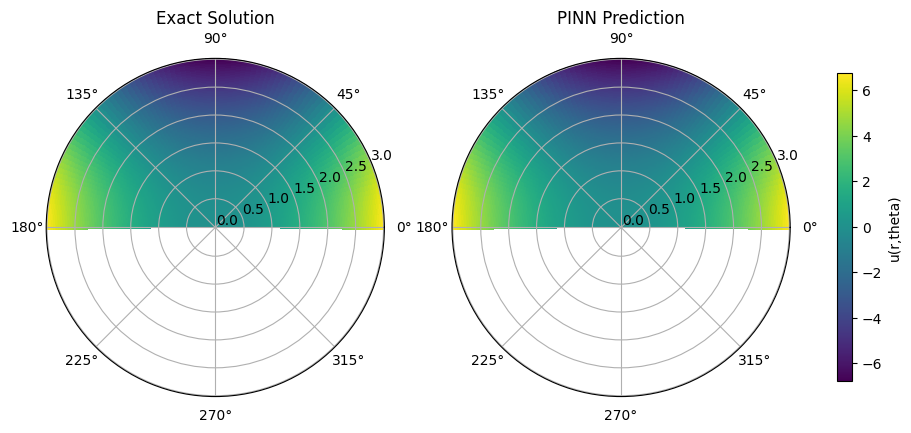

In [42]:
r_test = torch.linspace(0, 3, 100)
theta_test = torch.linspace(0, math.pi, 100)
R,Theta = torch.meshgrid(r_test, theta_test)
# (X[i,j], Y[i,j]) is the coordinate of the (i,j) point in the 2D (x,y) domain.
R_flat = R.reshape(-1,1)
Theta_flat = Theta.reshape(-1,1)

with torch.no_grad():
    u_pred = net(R_flat, Theta_flat).reshape(100, 100)
    u_exact = (3.0/4.0 * torch.pow(R_flat, 2) * torch.cos(2 * Theta_flat)).reshape(100, 100)

c0 = torch.mean(u_pred - u_exact)
u_exact += c0

vmin_val = min(u_exact.min(), u_pred.min())
vmax_val = max(u_exact.max(), u_pred.max())
# Create 1x2 polar subplots
fig, axes = plt.subplots(1, 2, subplot_kw={'projection':'polar'}, figsize=(12,5))

# First polar heatmap
c1 = axes[0].pcolormesh(Theta, R, u_exact, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
axes[0].set_title("Exact Solution")

# Second polar heatmap
c2 = axes[1].pcolormesh(Theta, R, u_pred, shading='auto', cmap='viridis', vmin=vmin_val, vmax=vmax_val)
axes[1].set_title("PINN Prediction")
# Single Colorbar
cbar = fig.colorbar(c1, ax=axes.ravel().tolist(), orientation='vertical', shrink=0.8)
cbar.set_label('u(r,theta)')

plt.show()


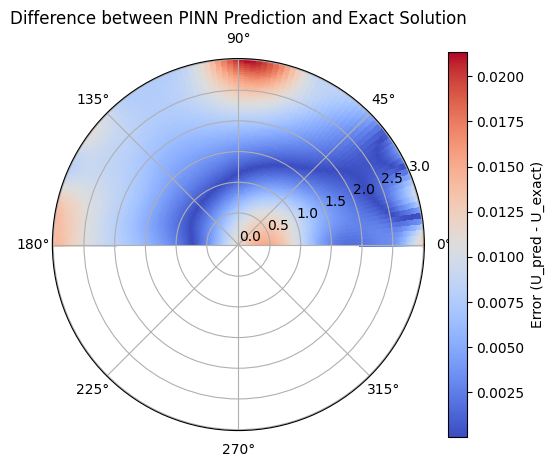

In [43]:
# Plot in a single polar subplot
fig, ax = plt.subplots(1, 1, subplot_kw={'projection': 'polar'}, figsize=(6,5))

c = ax.pcolormesh(Theta, R, abs(u_exact - u_pred), shading='auto', cmap='coolwarm')  # coolwarm shows +/− nicely
fig.colorbar(c, ax=ax, orientation='vertical', label='Error (U_pred - U_exact)')
ax.set_title("Difference between PINN Prediction and Exact Solution")

plt.show()

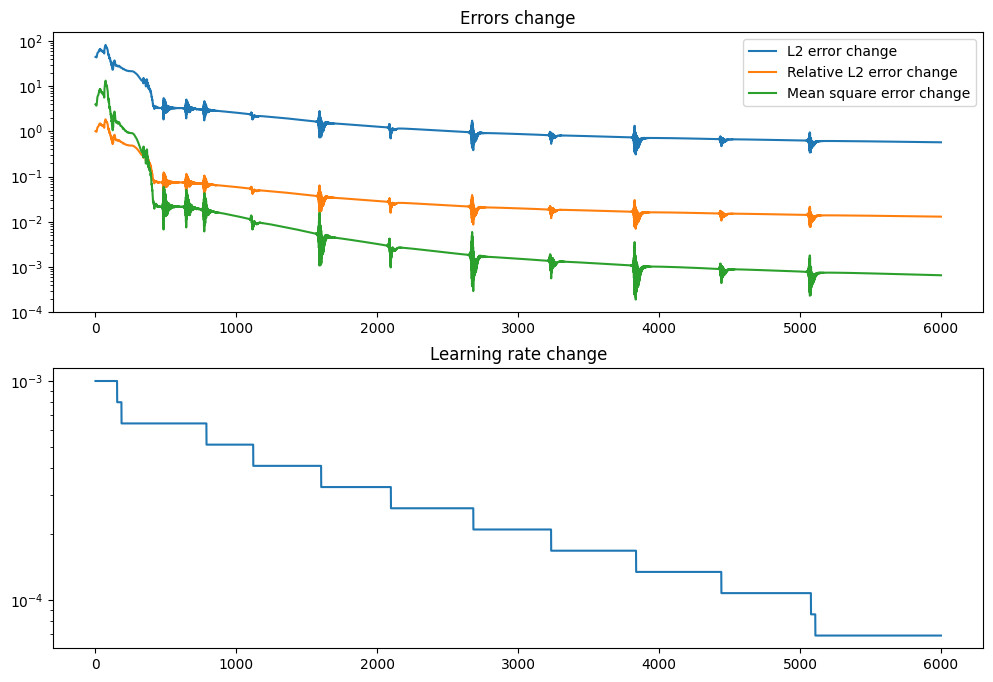

Minimum mean square error: 0.00019032014824915677
Minimum l2 error: 0.30848029255867004
Minimum relative l2 error: 0.006992154953782371


In [46]:
plt.figure(figsize=(12,8))

plt.subplot(2,1,1)
plt.semilogy(np.arange(0, 6001), l2_errors, label="L2 error change")
plt.semilogy(np.arange(0, 6001), l2_relative_errors, label="Relative L2 error change")
plt.semilogy(np.arange(0, 6001), mse_errors, label="Mean square error change")
plt.legend()
plt.title('Errors change')

plt.subplot(2,1,2)
plt.semilogy(np.arange(0, 6001), lrs, label="L2 error change")
plt.title('Learning rate change')

plt.show()
print(f"Minimum mean square error: {min(mse_errors)}")
print(f"Minimum l2 error: {min(l2_errors)}")
print(f"Minimum relative l2 error: {min(l2_relative_errors)}")